# ISIC 2024 - EDA
<img src="https://rohanmandrekar.netlify.app/project/skin-cancer-classification/featured_hu848b3a16dbf3cdbb5f8a90150897f466_52160_720x0_resize_lanczos_2.png" alt="Alt text" style="width:100%;" />

## Import Packages & Libraries

In [1]:
from pathlib import Path

import numpy as np 
import pandas as pd 
import seaborn as sns

from PIL import Image

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Import Data

In [2]:
root = Path('/kaggle/input/isic-2024-challenge')
image_root_path = root.joinpath('train-image/image')
train_df = pd.read_csv(root.joinpath('train-metadata.csv'))
train_df.head()

/tmp/ipykernel_18/2267951356.py:3: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(root.joinpath('train-metadata.csv'))


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


## Prepare for data analysis
### 1. Understand Data structure

In [3]:
print(train_df.info())
print(train_df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401059 entries, 0 to 401058
Data columns (total 55 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   isic_id                       401059 non-null  object 
 1   target                        401059 non-null  int64  
 2   patient_id                    401059 non-null  object 
 3   age_approx                    398261 non-null  float64
 4   sex                           389542 non-null  object 
 5   anatom_site_general           395303 non-null  object 
 6   clin_size_long_diam_mm        401059 non-null  float64
 7   image_type                    401059 non-null  object 
 8   tbp_tile_type                 401059 non-null  object 
 9   tbp_lv_A                      401059 non-null  float64
 10  tbp_lv_Aext                   401059 non-null  float64
 11  tbp_lv_B                      401059 non-null  float64
 12  tbp_lv_Bext                   401059 non-nul

### 2. Descriptive 

In [4]:
print(train_df.describe())

              target     age_approx  clin_size_long_diam_mm       tbp_lv_A  \
count  401059.000000  398261.000000           401059.000000  401059.000000   
mean        0.000980      58.012986                3.930827      19.974007   
std         0.031288      13.596165                1.743068       3.999489   
min         0.000000       5.000000                1.000000      -2.487115   
25%         0.000000      50.000000                2.840000      17.330821   
50%         0.000000      60.000000                3.370000      19.801910   
75%         0.000000      70.000000                4.380000      22.304628   
max         1.000000      85.000000               28.400000      48.189610   

         tbp_lv_Aext       tbp_lv_B    tbp_lv_Bext       tbp_lv_C  \
count  401059.000000  401059.000000  401059.000000  401059.000000   
mean       14.919247      28.281706      26.913015      34.786341   
std         3.529384       5.278676       4.482994       5.708469   
min        -9.080269 

### 3. Missing Values Analysis

In [5]:
missing_values = train_df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 isic_id                              0
target                               0
patient_id                           0
age_approx                        2798
sex                              11517
anatom_site_general               5756
clin_size_long_diam_mm               0
image_type                           0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Lext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                   

### 4. Visualizing missing values

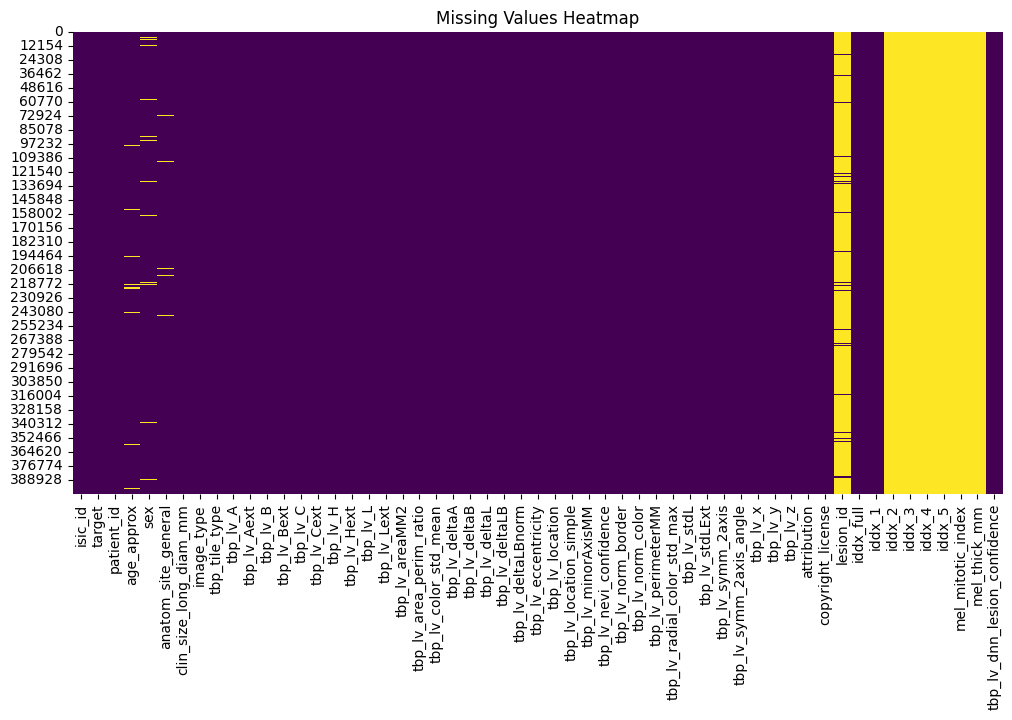

In [6]:
plt.figure(figsize=(12, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### 5. Distribution of Numerical Features

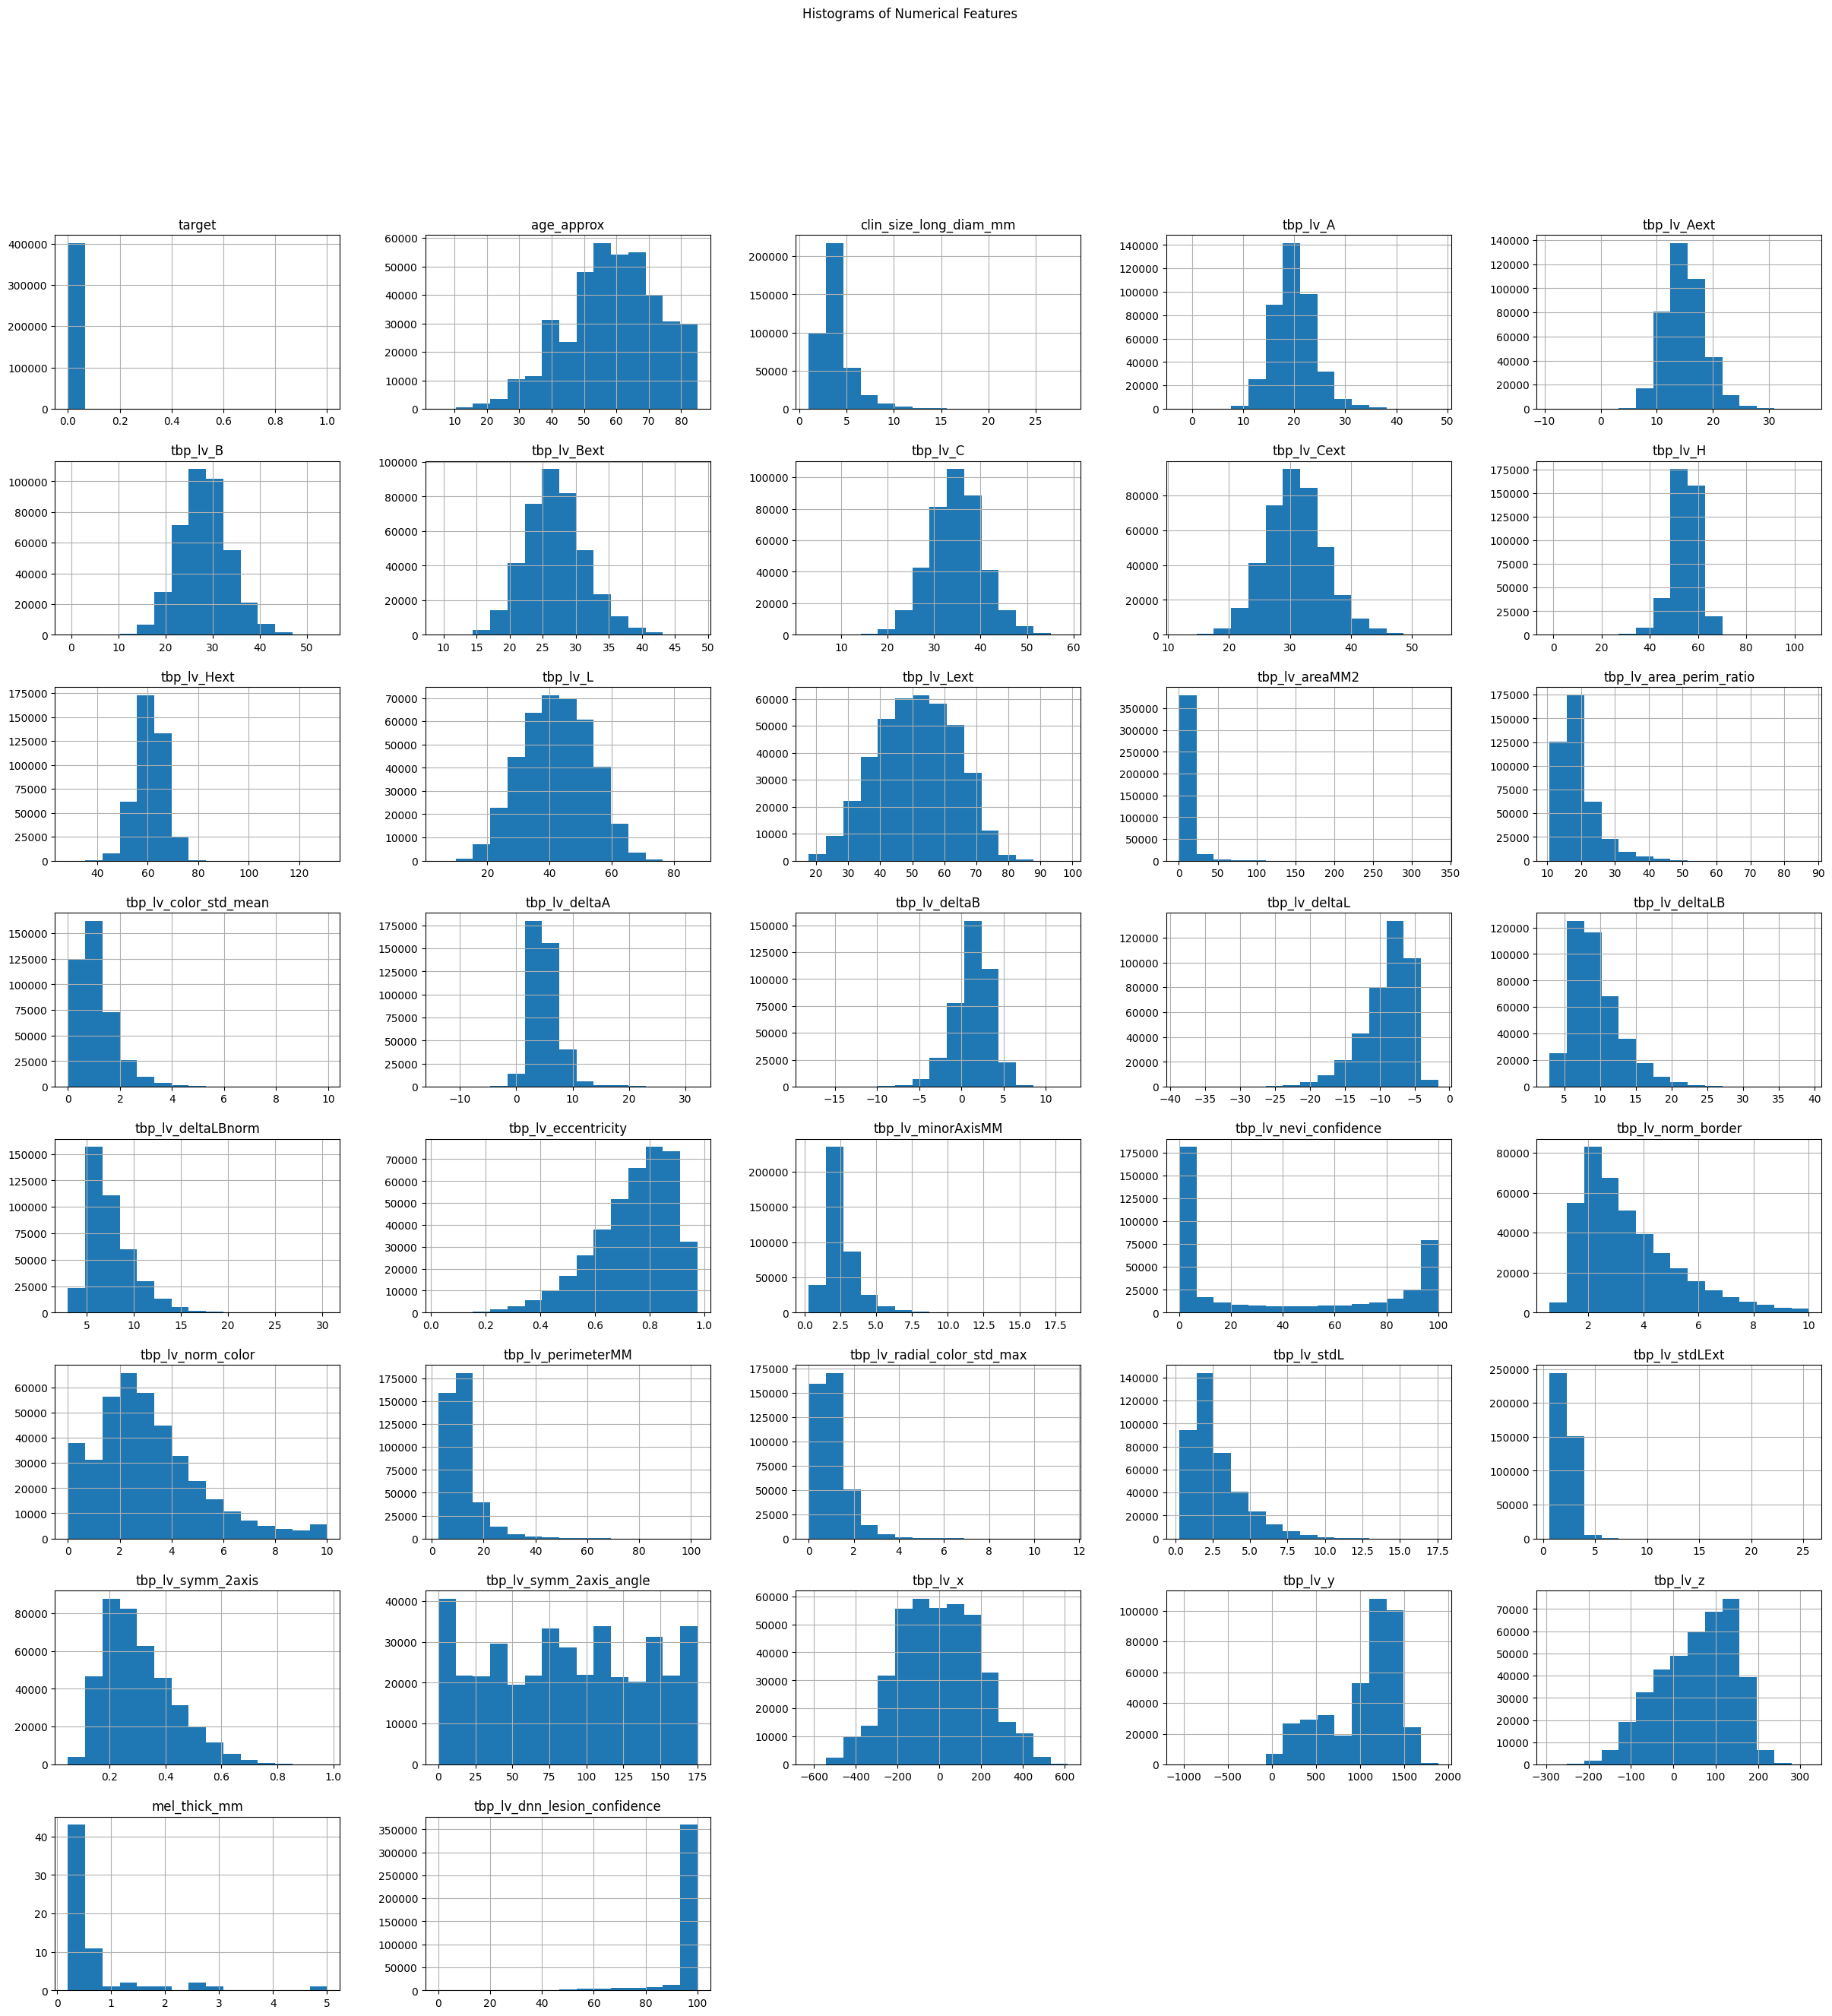

In [7]:
numerical_columns = train_df.select_dtypes(include=[np.number]).columns
train_df[numerical_columns].hist(bins=15, figsize=(30, 30), layout=(8, 5))
plt.suptitle('Histograms of Numerical Features')
plt.show()

### 6. Categorical Feature Analysis

In [8]:
categorical_columns = train_df.select_dtypes(include=[object]).columns
print(list(categorical_columns))

['isic_id', 'patient_id', 'sex', 'anatom_site_general', 'image_type', 'tbp_tile_type', 'tbp_lv_location', 'tbp_lv_location_simple', 'attribution', 'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index']


### 7. Correlation Analysis

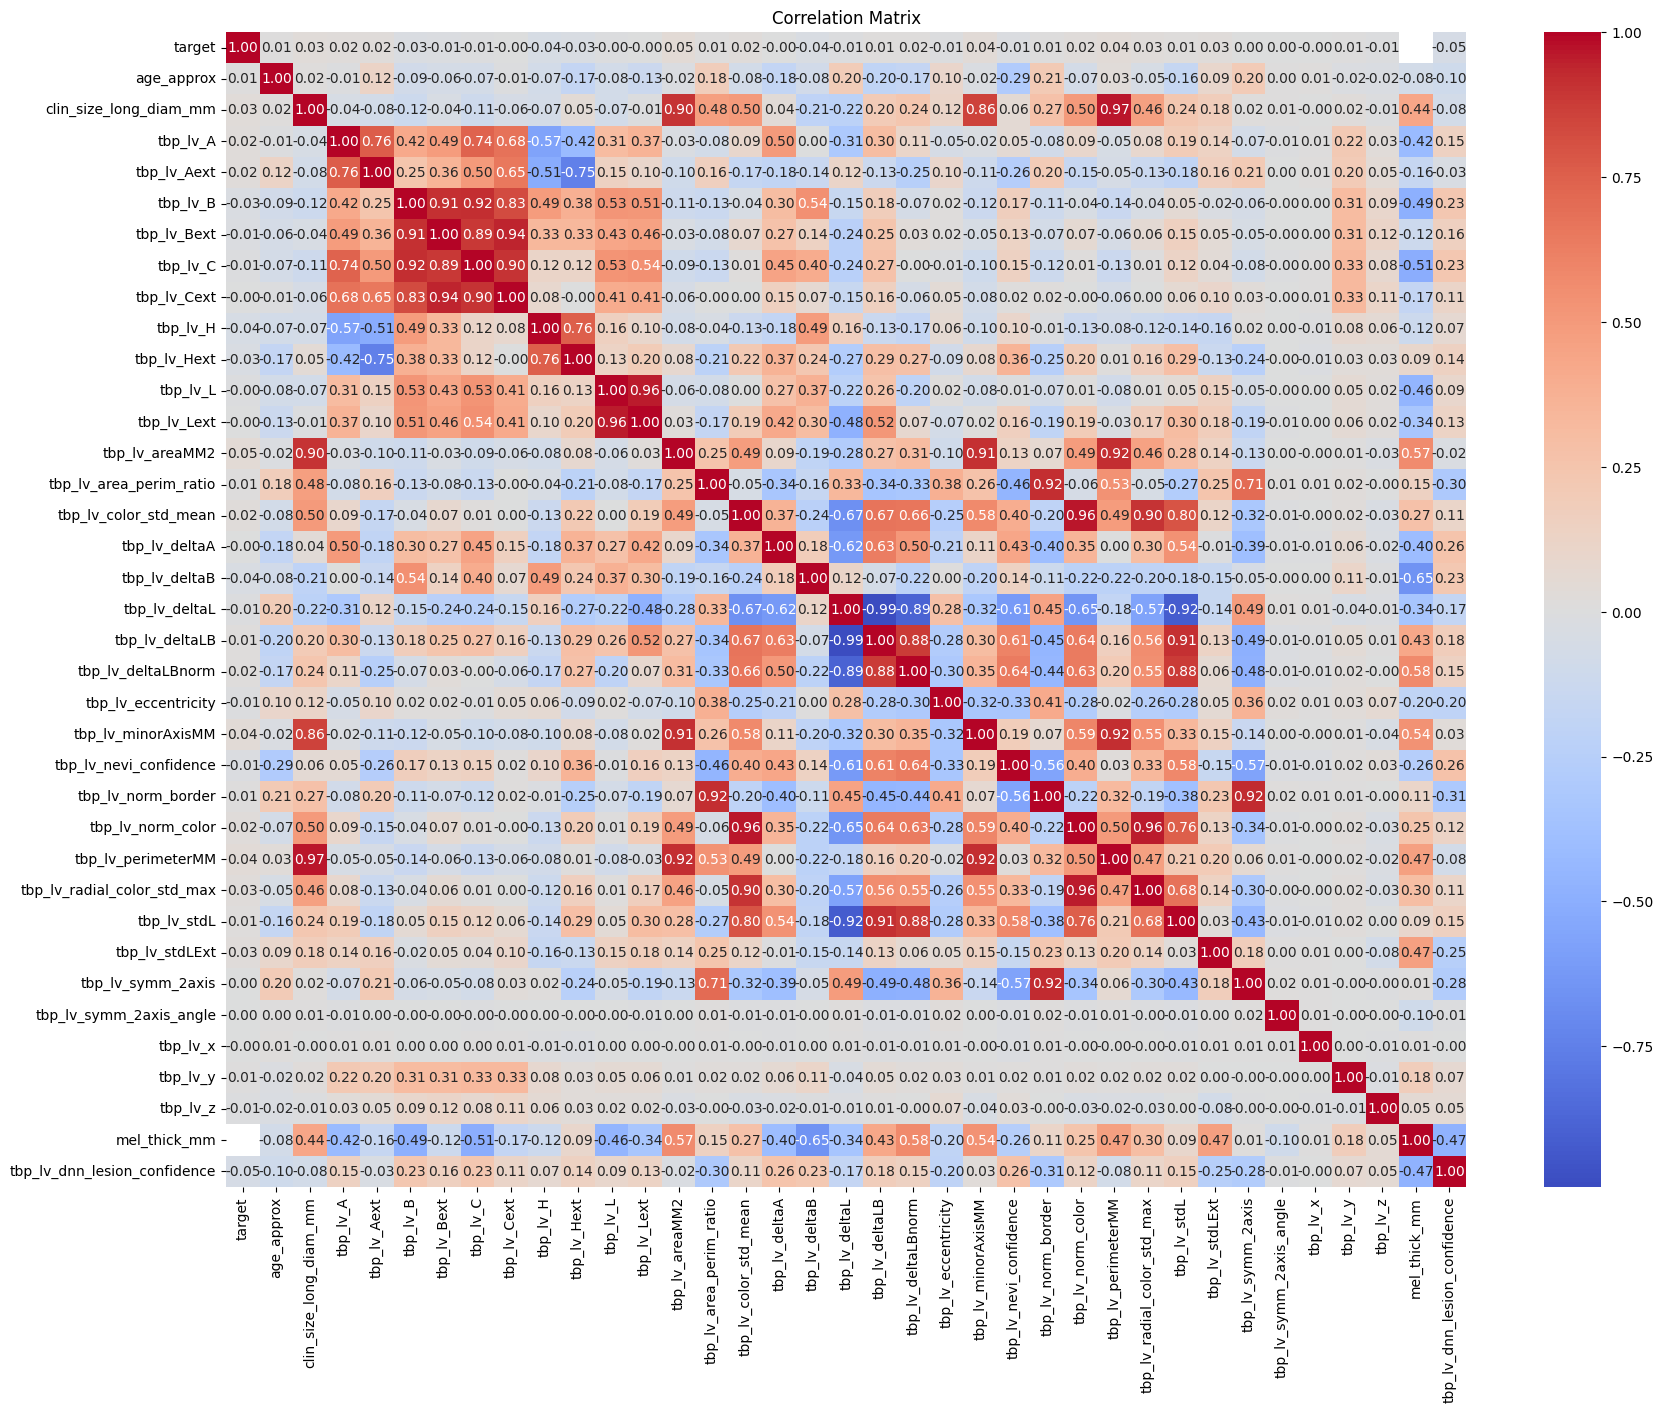

In [9]:
numerical_columns = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numerical_columns].corr()

# Plotting the correlation matrix
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### 8. Visualization of Important Features

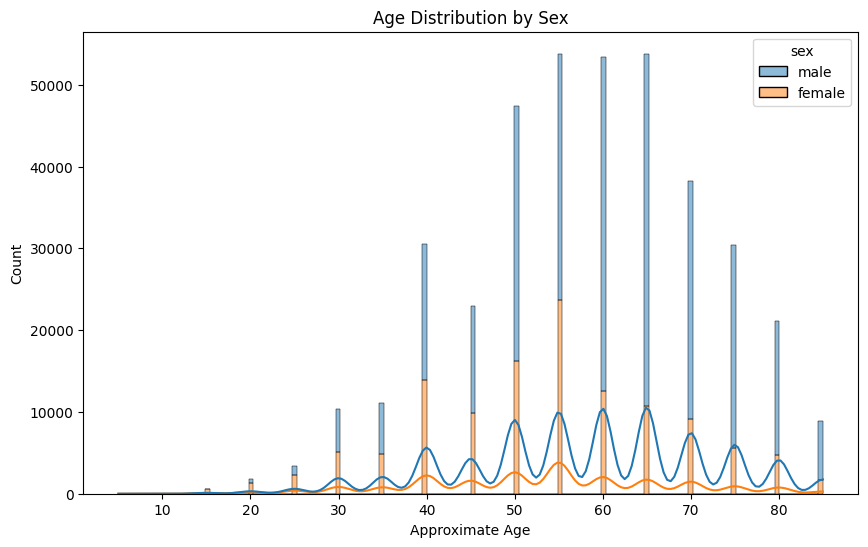

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='age_approx', hue='sex', multiple='stack', kde=True)
plt.title('Age Distribution by Sex')
plt.xlabel('Approximate Age')
plt.ylabel('Count')
plt.show()

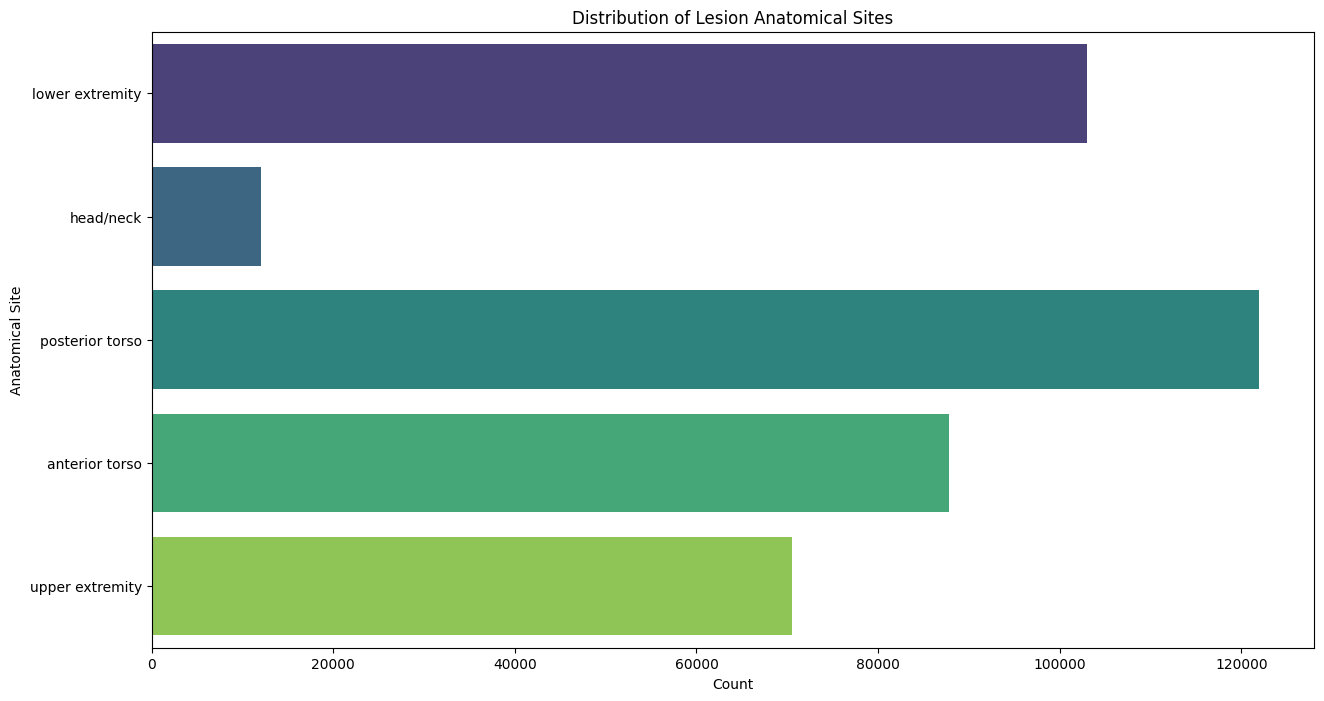

In [11]:
plt.figure(figsize=(15, 8))
sns.countplot(y='anatom_site_general', data=train_df, palette='viridis')
plt.title('Distribution of Lesion Anatomical Sites')
plt.xlabel('Count')
plt.ylabel('Anatomical Site')
plt.show()

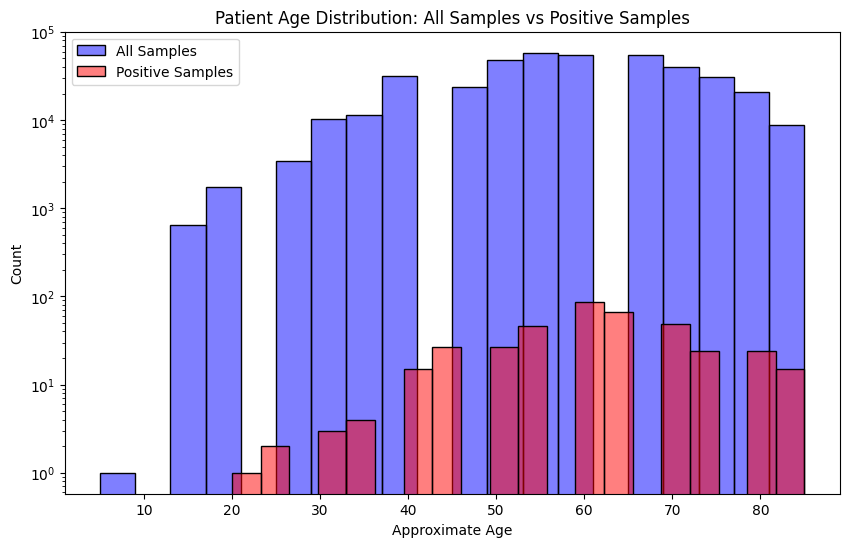

In [12]:
# Assuming 'target' is the column name for the target variable
target_column = 'target'  # Replace with the actual name of your target column
age_column = 'age_approx'  # Column representing patient ages

# Filter the dataset to include only positive samples
positive_samples = train_df[train_df[target_column] == 1]

# Plotting age distribution for all samples and positive samples
plt.figure(figsize=(10, 6))

# Plot for all samples
sns.histplot(data=train_df, x=age_column, kde=False, color='blue', label='All Samples', alpha=0.5, bins=20)

# Plot for positive samples
sns.histplot(data=positive_samples, x=age_column, kde=False, color='red', label='Positive Samples', alpha=0.5, bins=20)
plt.yscale('log')
plt.title('Patient Age Distribution: All Samples vs Positive Samples')
plt.xlabel('Approximate Age')
plt.ylabel('Count')
plt.legend()
plt.show()

Melanoma, while rare in children, can affect adults across a broad age range. According to the Australian Institute of Health and Welfare, the distribution of melanoma cases by age in 2021 was as follows:

- **7.9%** of diagnosed cases were individuals aged **under 40 years**.
- **10.7%** were aged **40-49 years**.
- **17.8%** were aged **50-59 years**.
- **23.9%** were aged **60-69 years**.
- **23.7%** were aged **70-79 years**.
- **16%** were aged **80 years or older**.

Analysis of the patient age distribution, comparing positive melanoma samples with all samples, reveals that the distribution aligns with these statistics. Specifically:

- **Positive melanoma samples** tend to show a higher concentration of cases in older age groups. This is consistent with the data that shows increasing melanoma incidence with age.
- The **histogram of positive samples** shows that the frequency of positive melanoma cases increases significantly in the age groups of **60 years and older**, reflecting the higher percentages of diagnosed cases in these age brackets.
- The **logarithmic scale** of the y-axis highlights the differences in frequency more clearly, showing that while melanoma is relatively rare in younger age groups, it becomes more common in older populations.

This visualization reinforces the understanding that while melanoma can occur at any age, the risk significantly increases as people grow older, aligning with national health statistics and supporting the need for targeted screening and prevention efforts in older age groups.

[Link](https://dermnetnz.org/topics/melanoma?gad_source=1&gclid=Cj0KCQjw-5y1BhC-ARIsAAM_oKn6yU0Fgl5sumslP2ONwhRkzp9mDrkp_b3DY6xvCwIz5UpB_qlBtbAaAlUtEALw_wcB)


# Finalize
Let's show some love and support! 👍